<a href="https://colab.research.google.com/github/NateTAGA/CMPS451_Spring25/blob/Assignment2/soil_temp_forecast_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌱 Soil Temperature Forecasting (LSTM & BiLSTM)

This Colab notebook loads soil temperature data from a CSV file, preprocesses it, and trains both LSTM and BiLSTM models to forecast the next 6 months.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense
import matplotlib.pyplot as plt


In [2]:
from google.colab import files
uploaded = files.upload()


Saving psspredict10.csv to psspredict10 (1).csv


In [3]:
df = pd.read_csv("psspredict10.csv")
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
monthly_temp = df['temp'].resample('M').mean()

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(monthly_temp.values.reshape(-1, 1))

def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_values, window_size)
X_train, X_test = X[:-6], X[-6:]
y_train, y_test = y[:-6], y[-6:]


<ipython-input-3-cee71c235b93>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df['temp'].resample('M').mean()


In [4]:
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(window_size, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0)

bilstm_model = Sequential([
    Bidirectional(LSTM(64, activation='relu'), input_shape=(window_size, 1)),
    Dense(1)
])
bilstm_model.compile(optimizer='adam', loss='mse')
bilstm_model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step


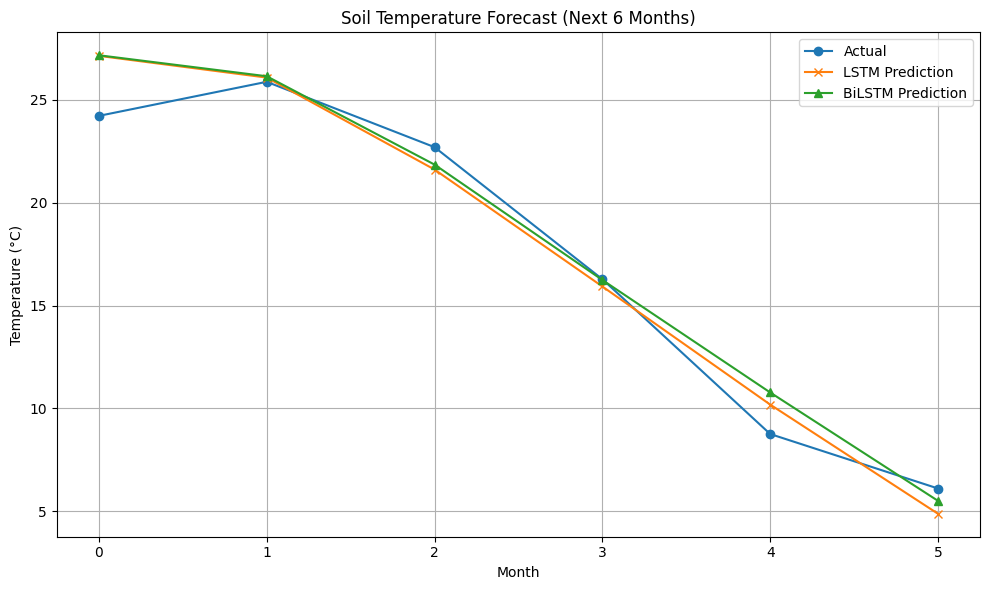

In [5]:
lstm_preds = lstm_model.predict(X_test)
bilstm_preds = bilstm_model.predict(X_test)

lstm_preds_actual = scaler.inverse_transform(lstm_preds)
bilstm_preds_actual = scaler.inverse_transform(bilstm_preds)
y_test_actual = scaler.inverse_transform(y_test)

plt.figure(figsize=(10, 6))
plt.plot(y_test_actual, label='Actual', marker='o')
plt.plot(lstm_preds_actual, label='LSTM Prediction', marker='x')
plt.plot(bilstm_preds_actual, label='BiLSTM Prediction', marker='^')
plt.title('Soil Temperature Forecast (Next 6 Months)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
